# Analyze time series data of key air pollutants (PM2.5, PM10, SO₂, CO, Ozone) in Delhi to identify trends, correlations, and potential solutions for improving air quality.

In [ ]:
from google.colab import files
uploaded = files.upload()
import pandas as pd
data = pd.read_csv('Delhi air pollution.csv')

Saving Delhi air pollution.csv to Delhi air pollution (1).csv


In [ ]:
data['to_date'] = pd.to_datetime(data['to_date'])
data['from_date'] = pd.to_datetime(data['from_date'])

In [ ]:
data = data.dropna(subset=['to_date', 'from_date'])

In [ ]:
air_quality_columns = ['pm25', 'pm10', 'SO2', 'CO', 'Ozone']
data[air_quality_columns] = data[air_quality_columns].apply(lambda col: col.map(lambda x: x if x >= 0 else pd.NA))


In [ ]:

data['pm25'] = data['pm25'].fillna(data['pm25'].mean())
data['pm10'] = data['pm10'].fillna(data['pm10'].mean())
data['SO2'] = data['SO2'].fillna(data['SO2'].mean())
data['CO'] = data['CO'].fillna(data['CO'].mean())
data['Ozone'] = data['Ozone'].fillna(data['Ozone'].mean())

data = data.infer_objects(copy=False)

pd.set_option('future.no_silent_downcasting', True)


In [ ]:
data = data.drop_duplicates()


In [ ]:
numeric_columns = ['pm25', 'pm10', 'SO2', 'CO', 'Ozone']
data[numeric_columns] = data[numeric_columns].apply(pd.to_numeric, errors='coerce')

In [ ]:
data.to_csv('Delhi air pollution.csv', index=False)

In [ ]:
print("Data Cleaning Completed.")
print("Cleaned dataset summary:")
print(data.info())
print("\n")
print(data.head())

Data Cleaning Completed.
Cleaned dataset summary:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4530 entries, 0 to 4529
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   id          4530 non-null   int64         
 1   city        4530 non-null   object        
 2   site_name   4530 non-null   object        
 3   site        4530 non-null   object        
 4   state       4530 non-null   object        
 5   query_name  4530 non-null   object        
 6   to_date     4530 non-null   datetime64[ns]
 7   to_time     4530 non-null   object        
 8   from_date   4530 non-null   datetime64[ns]
 9   from_time   4530 non-null   object        
 10  pm25        4530 non-null   float64       
 11  pm10        4530 non-null   float64       
 12  SO2         4530 non-null   float64       
 13  CO          4530 non-null   float64       
 14  Ozone       4530 non-null   float64       
dtypes: datetime64[ns](2), 

In [ ]:
data.describe()

,id,to_date,from_date,pm25,pm10,SO2,CO,Ozone
count,4530.000000,4530,4530,4530.000000,4530.000000,4530.000000,4530.000000,4530.000000
mean,2265.500000,2018-07-13 10:04:36.556291328,2018-07-12 10:04:36.556291584,122.291823,254.367005,15.123957,1.686377,34.332914
min,1.000000,2016-01-02 00:00:00,2016-01-01 00:00:00,1.260000,5.870000,0.410000,0.000000,0.040000
25%,1133.250000,2017-04-10 00:00:00,2017-04-09 00:00:00,64.022500,180.017500,15.123957,1.120000,25.102500
50%,2265.500000,2018-07-12 00:00:00,2018-07-11 00:00:00,122.291823,254.367005,15.123957,1.686377,34.332914
75%,3397.750000,2019-10-21 00:00:00,2019-10-20 00:00:00,124.962500,274.825000,15.123957,1.720000,34.665000
max,4530.000000,2021-01-19 00:00:00,2021-01-18 00:00:00,966.430000,974.920000,87.540000,32.870000,176.470000
std,1307.842689,NaN,NaN,84.376197,128.415206,6.432784,1.264781,16.498180


## 2. Data visualization


plotting air pollution levels over time

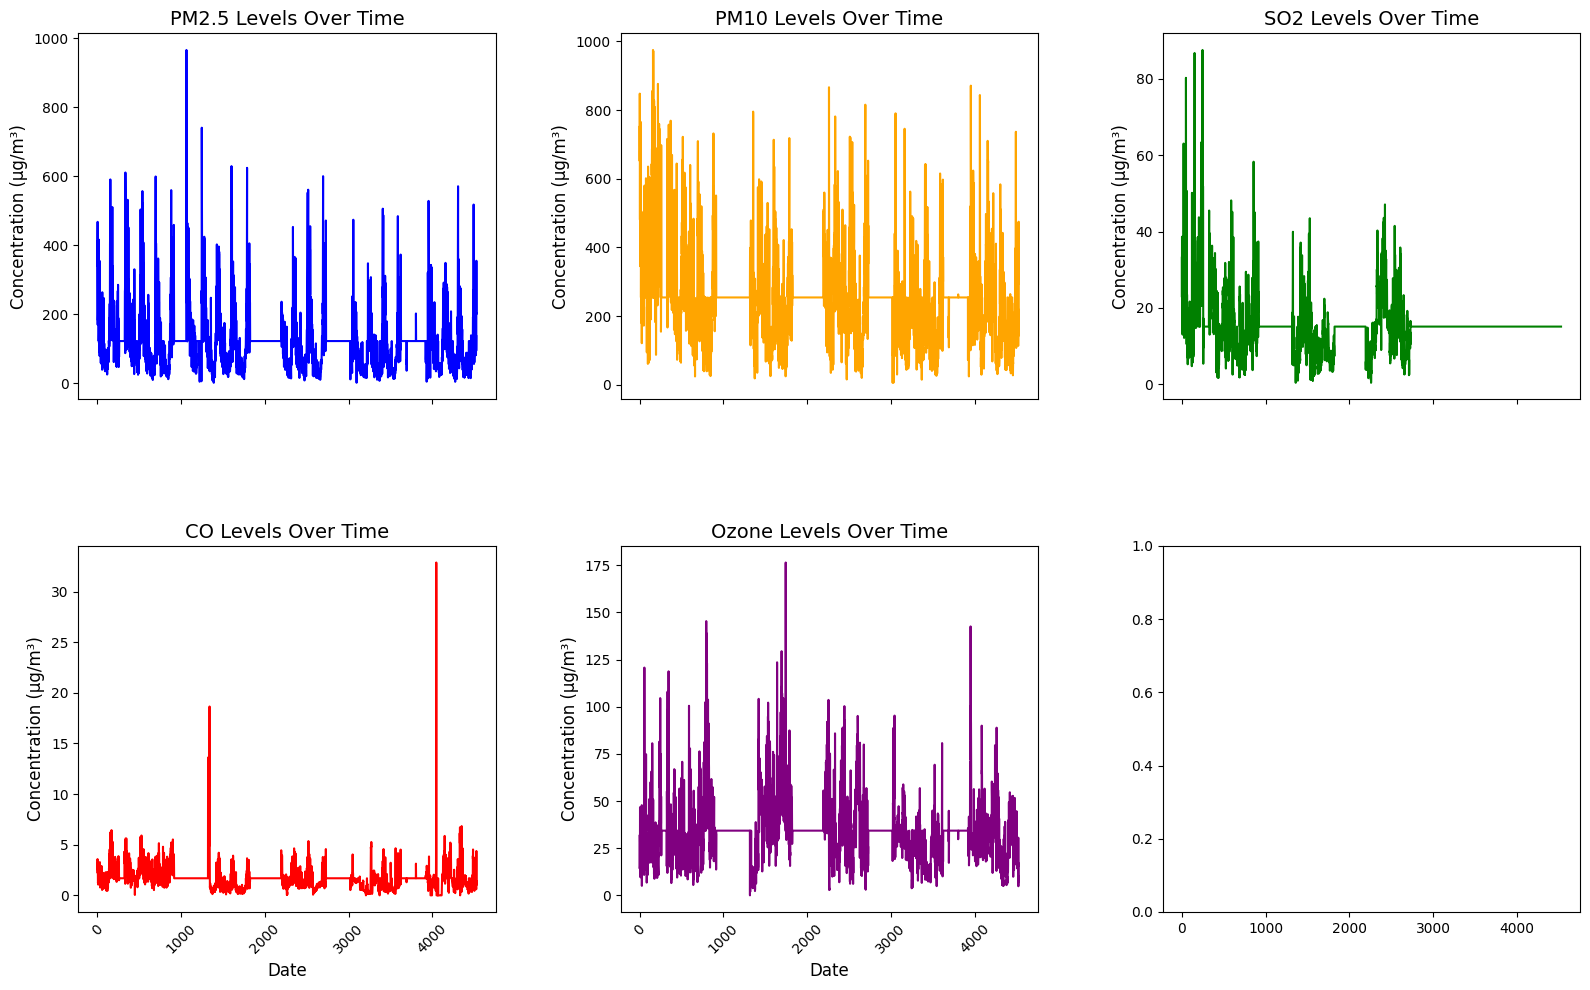

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 3, figsize=(16, 10), sharex=True)

pollutants = ['pm25', 'pm10', 'SO2', 'CO', 'Ozone']
colors = ['blue', 'orange', 'green', 'red', 'purple']
titles = ['PM2.5', 'PM10', 'SO2', 'CO', 'Ozone']

axes = axes.flatten()

for i, pollutant in enumerate(pollutants):
    sns.lineplot(data=data[pollutant], ax=axes[i], color=colors[i])
    axes[i].set_title(f'{titles[i]} Levels Over Time', fontsize=14)
    axes[i].set_xlabel('Date', fontsize=12)
    axes[i].set_ylabel('Concentration (µg/m³)', fontsize=12)
    axes[i].tick_params(axis='x', rotation=45)


plt.tight_layout()
plt.subplots_adjust(hspace=0.4, wspace=0.3)
plt.show()


 ### Heat map of pollution levels by site and time

pm25

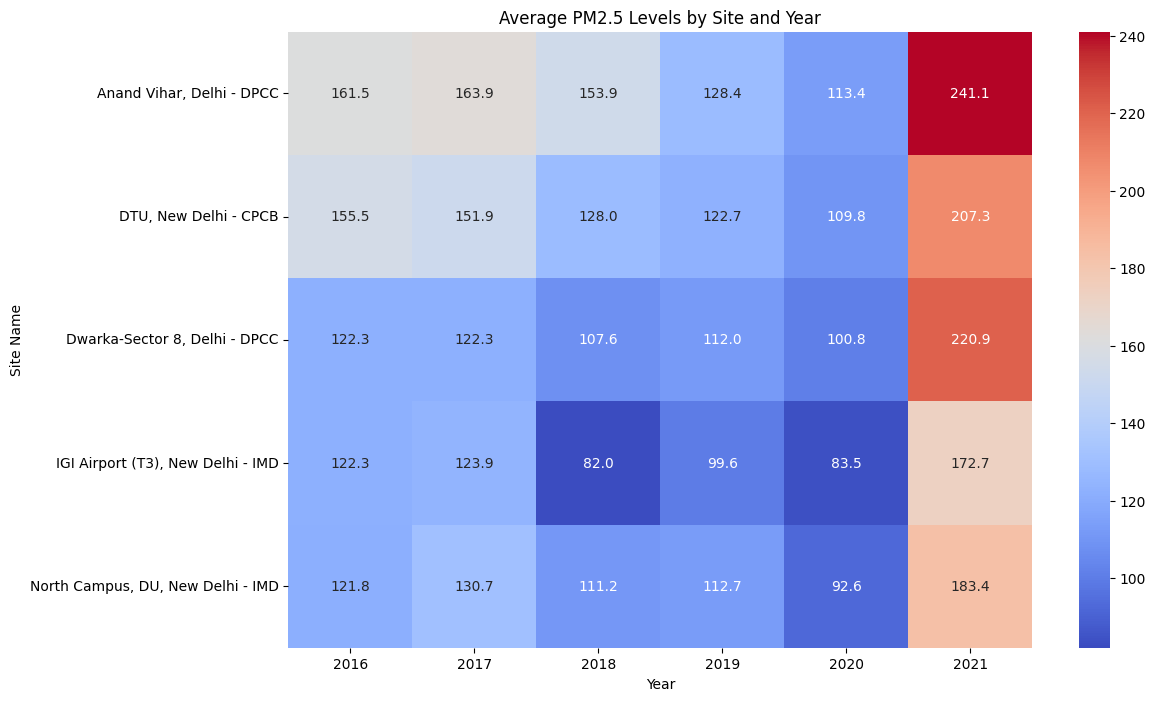

In [ ]:

heatmap_data = data.pivot_table(values='pm25', index='site_name', columns=data['from_date'].dt.year, aggfunc='mean')

plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, cmap='coolwarm', annot=True, fmt=".1f")
plt.title('Average PM2.5 Levels by Site and Year')
plt.xlabel('Year')
plt.ylabel('Site Name')
plt.show()


pm10

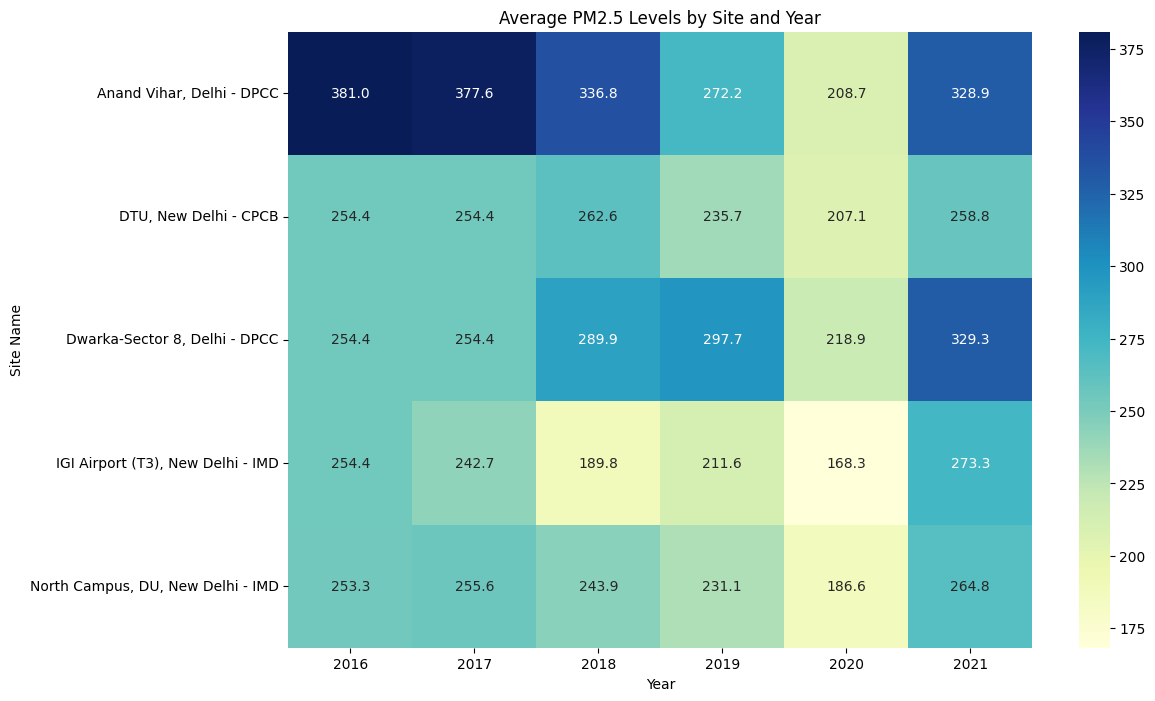

In [ ]:

heatmap_data = data.pivot_table(values='pm10', index='site_name', columns=data['from_date'].dt.year, aggfunc='mean')

plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, cmap='YlGnBu', annot=True, fmt=".1f")
plt.title('Average PM2.5 Levels by Site and Year')
plt.xlabel('Year')
plt.ylabel('Site Name')
plt.show()


SO2

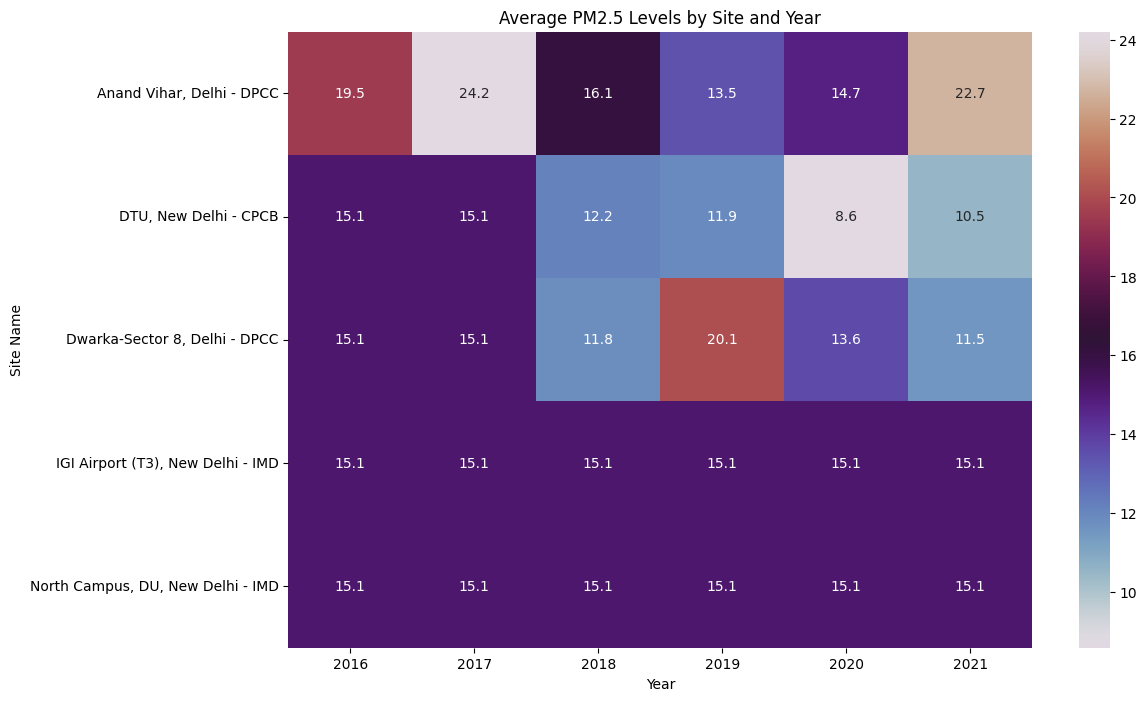

In [ ]:

heatmap_data = data.pivot_table(values='SO2', index='site_name', columns=data['from_date'].dt.year, aggfunc='mean')

plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, cmap='twilight', annot=True, fmt=".1f")
plt.title('Average PM2.5 Levels by Site and Year')
plt.xlabel('Year')
plt.ylabel('Site Name')
plt.show()


CO

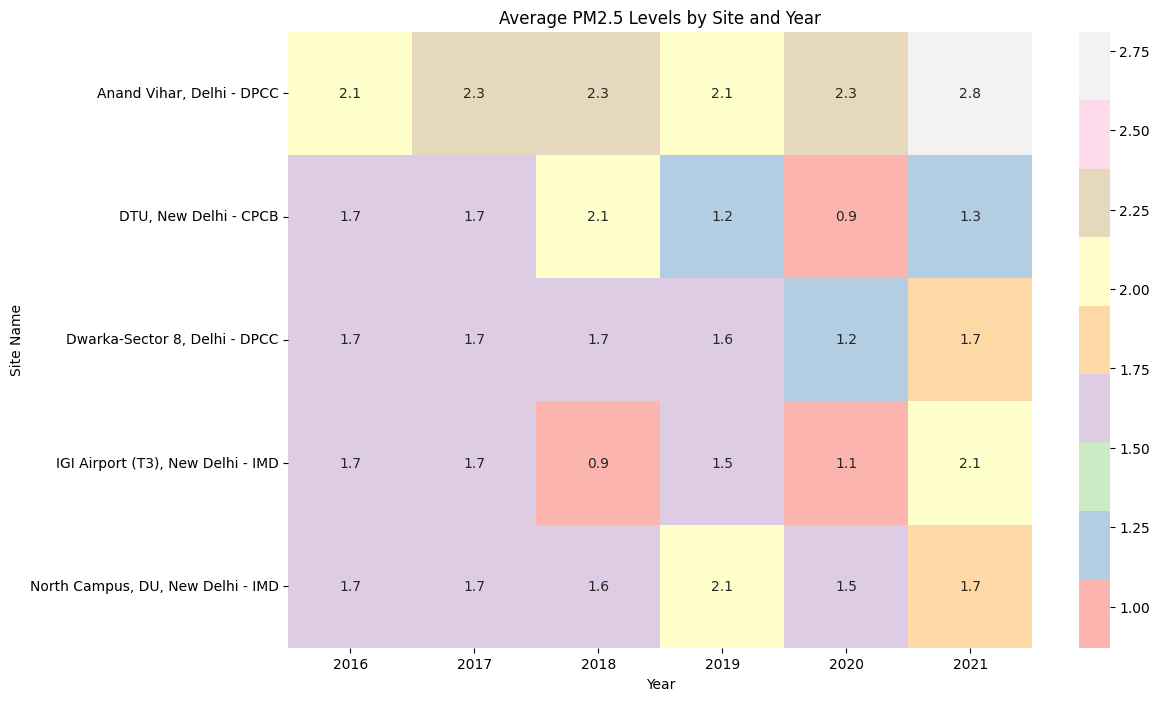

In [ ]:

heatmap_data = data.pivot_table(values='CO', index='site_name', columns=data['from_date'].dt.year, aggfunc='mean')

plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, cmap='Pastel1', annot=True, fmt=".1f")
plt.title('Average PM2.5 Levels by Site and Year')
plt.xlabel('Year')
plt.ylabel('Site Name')
plt.show()


Ozone

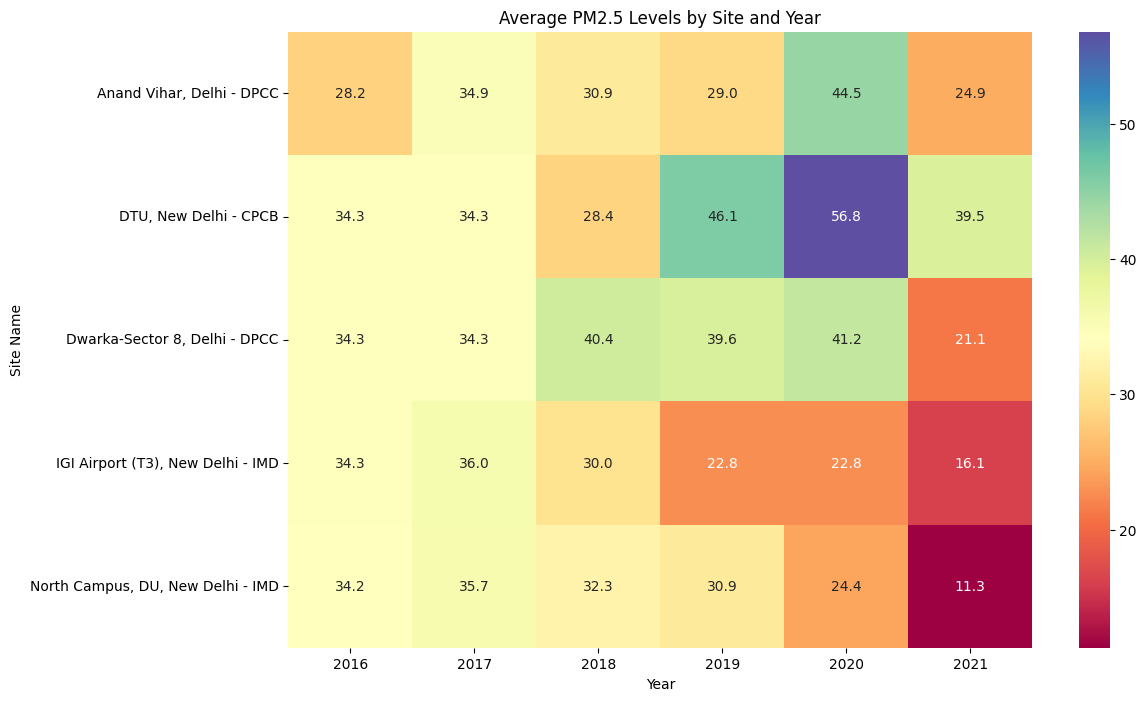

In [ ]:

heatmap_data = data.pivot_table(values='Ozone', index='site_name', columns=data['from_date'].dt.year, aggfunc='mean')

plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, cmap='Spectral', annot=True, fmt=".1f")
plt.title('Average PM2.5 Levels by Site and Year')
plt.xlabel('Year')
plt.ylabel('Site Name')
plt.show()


### Pie chart for different pollutants over different years

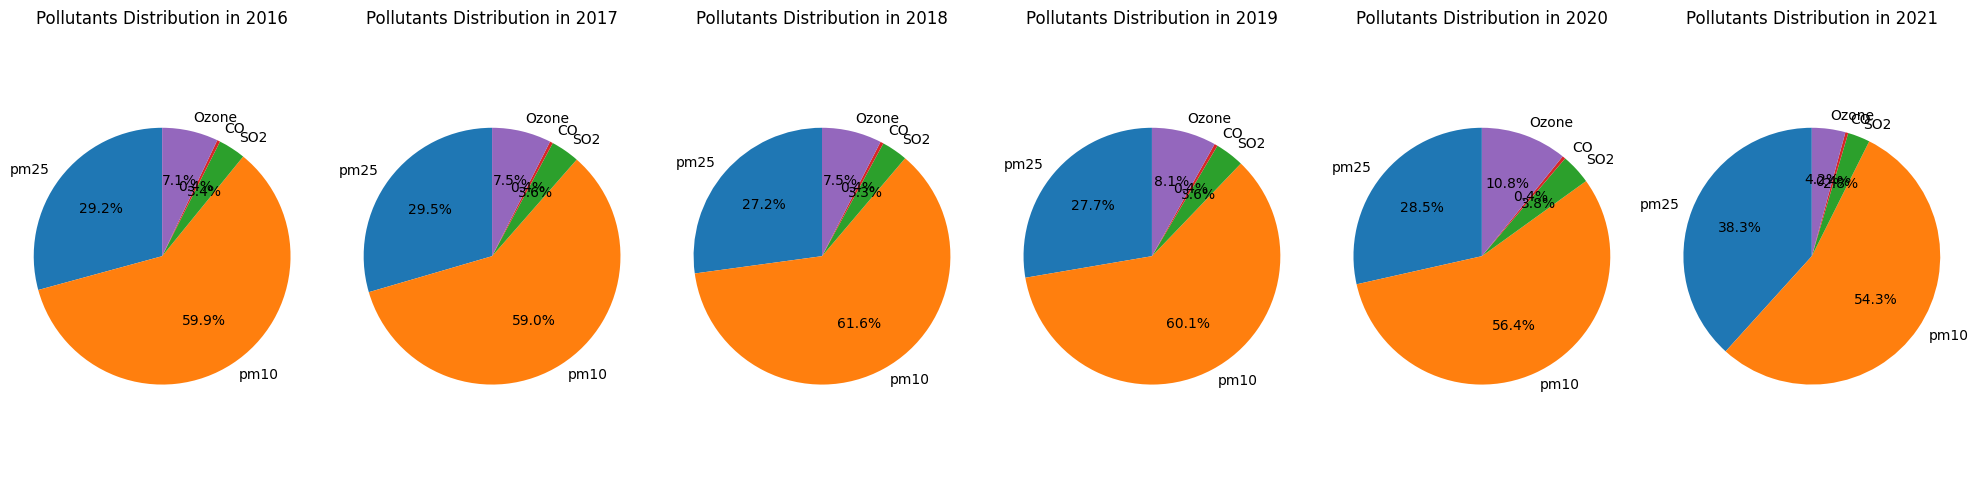

In [ ]:
data['Year'] = data['from_date'].dt.year

pollutants = ['pm25', 'pm10', 'SO2', 'CO', 'Ozone']
titles = ['PM2.5', 'PM10', 'SO2', 'CO', 'Ozone']

years = data['Year'].unique()

fig, axes = plt.subplots(1, len(years), figsize=(20, 5))

for ax, year in zip(axes, years):
    avg_levels = data[data['Year'] == year][pollutants].mean()

    wedges, texts, autotexts = ax.pie(
        avg_levels,
        labels=avg_levels.index,
        autopct='%1.1f%%',
        startangle=90
    )

    ax.set_title(f'Pollutants Distribution in {year}')

    ax.axis('equal')

plt.tight_layout()
plt.show()

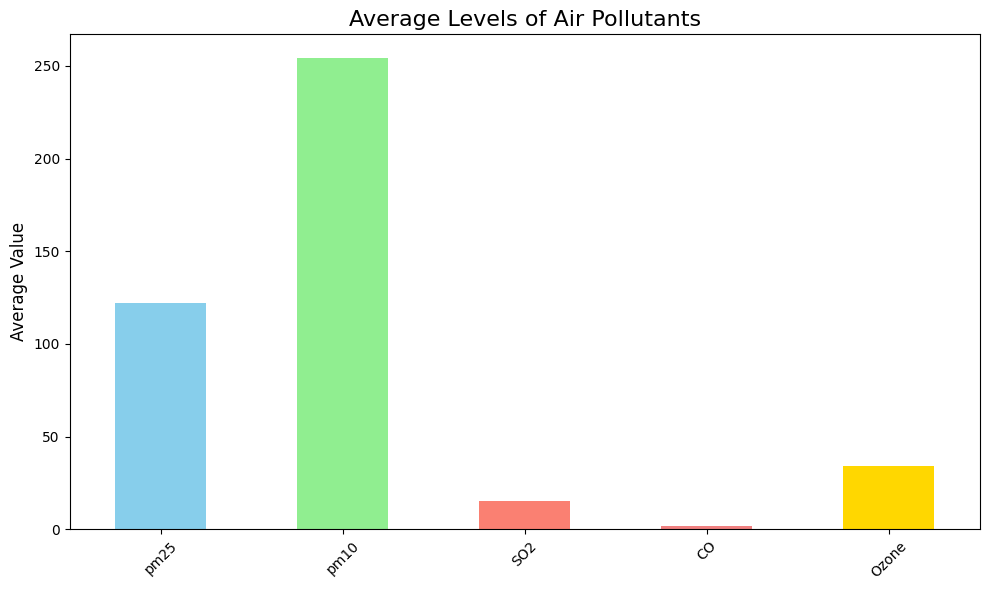

In [ ]:
summary = data[['pm25', 'pm10', 'SO2', 'CO', 'Ozone']].mean()

plt.figure(figsize=(10,6))
summary.plot(kind='bar', color=['skyblue', 'lightgreen', 'salmon', 'lightcoral', 'gold'])

plt.title('Average Levels of Air Pollutants', fontsize=16)
plt.ylabel('Average Value', fontsize=12)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

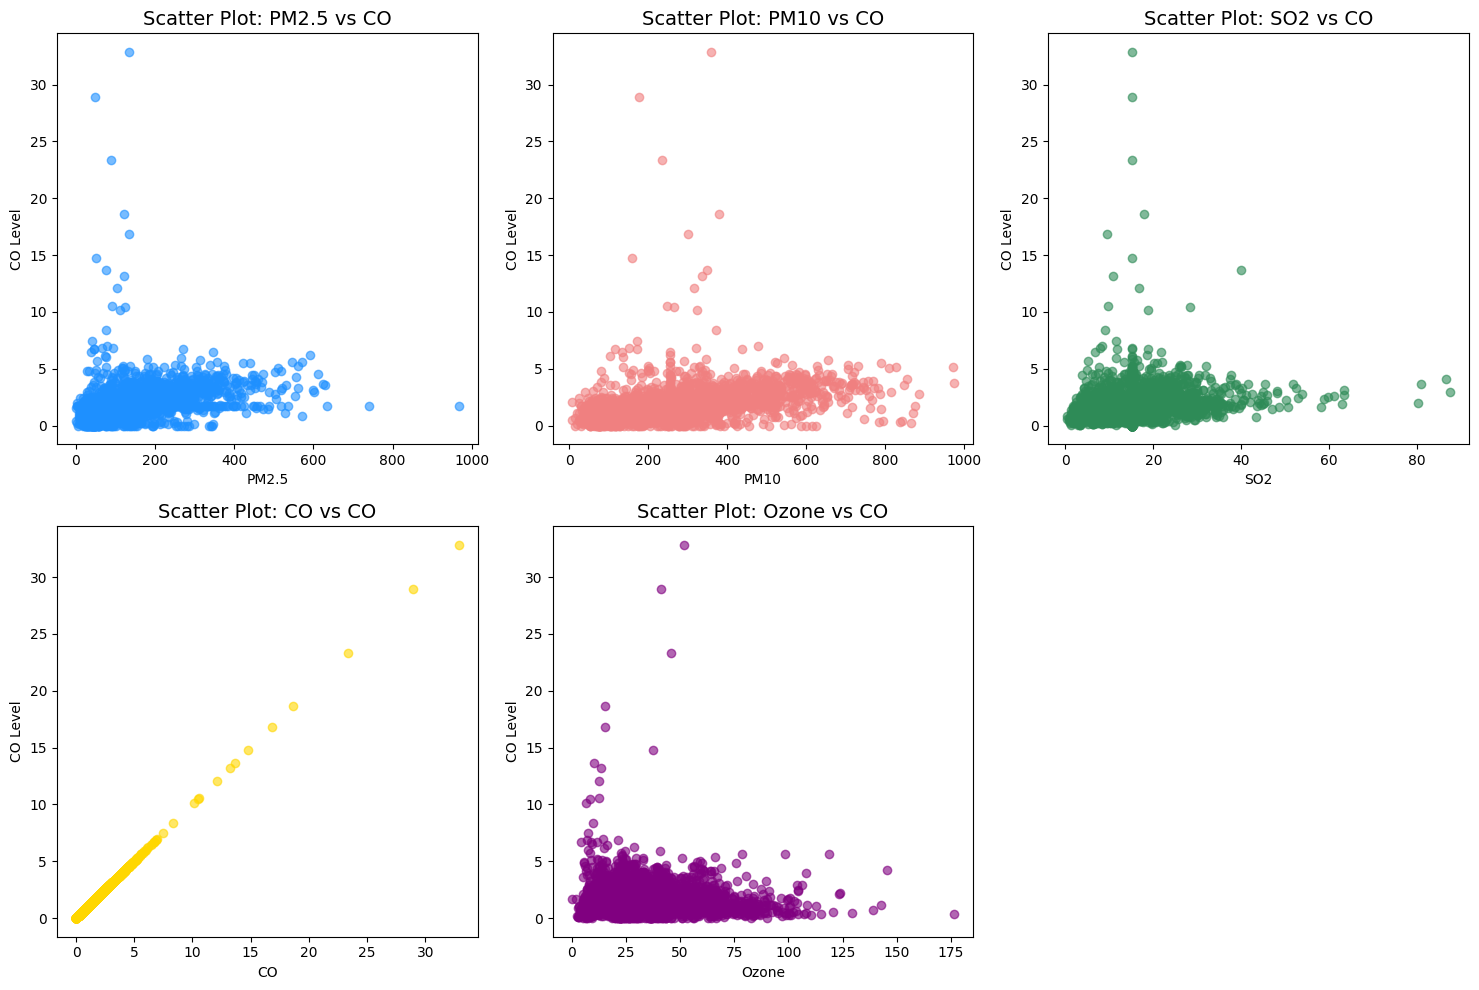

In [ ]:
pollutants = ['pm25', 'pm10', 'SO2', 'CO', 'Ozone']
titles = ['PM2.5', 'PM10', 'SO2', 'CO', 'Ozone']
colors = ['dodgerblue', 'lightcoral', 'seagreen', 'gold', 'purple']

fig, axs = plt.subplots(2, 3, figsize=(15,10))

for i, pollutant in enumerate(pollutants):
    row, col = divmod(i, 3)
    axs[row, col].scatter(data[pollutant], data['CO'], color=colors[i], alpha=0.6)
    axs[row, col].set_title(f'Scatter Plot: {titles[i]} vs CO', fontsize=14)
    axs[row, col].set_xlabel(f'{titles[i]}', fontsize=10)
    axs[row, col].set_ylabel('CO Level', fontsize=10)

plt.tight_layout()

fig.delaxes(axs[1, 2])

plt.show()

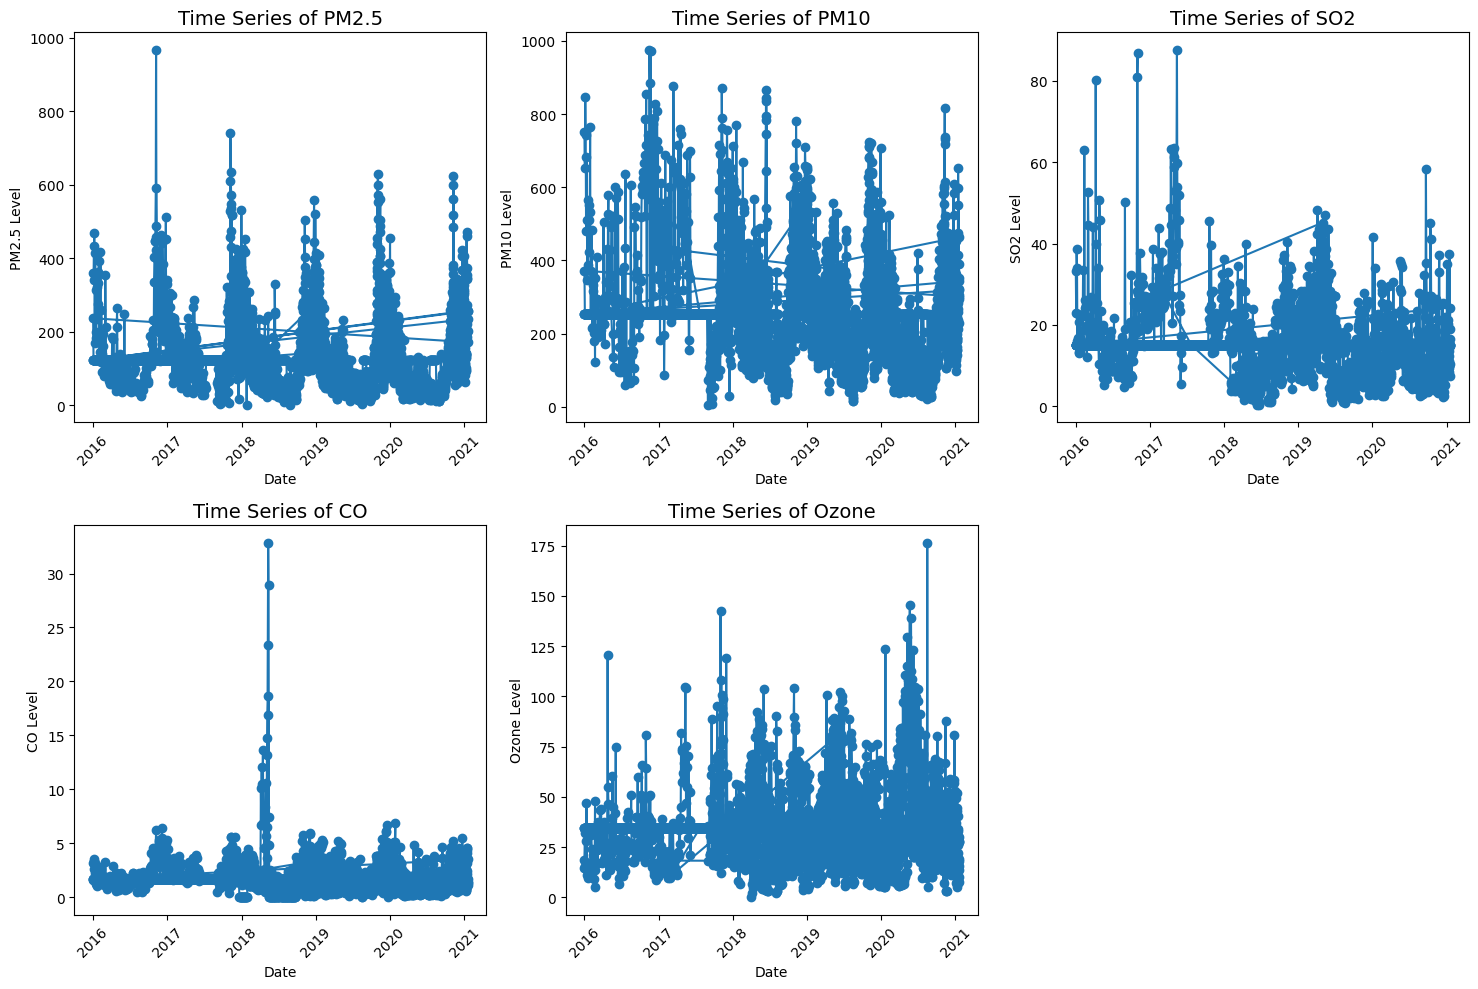

In [ ]:
data['from_date'] = pd.to_datetime(data['from_date'], format='%d-%b-%y')

fig, axs = plt.subplots(2, 3, figsize=(15,10))

pollutants = ['pm25', 'pm10', 'SO2', 'CO', 'Ozone']
titles = ['PM2.5', 'PM10', 'SO2', 'CO', 'Ozone']

for i, pollutant in enumerate(pollutants):
    row, col = divmod(i, 3)
    axs[row, col].plot(data['from_date'], data[pollutant], marker='o', linestyle='-', label=pollutant)
    axs[row, col].set_title(f'Time Series of {titles[i]}', fontsize=14)
    axs[row, col].set_xlabel('Date', fontsize=10)
    axs[row, col].set_ylabel(f'{titles[i]} Level', fontsize=10)
    axs[row, col].tick_params(axis='x', rotation=45)

plt.tight_layout()

fig.delaxes(axs[1, 2])

plt.show()

# The overall takeaway is that particulate matter pollution (both PM2.5 and PM10) seems to be a persistent and severe problem, while gases like CO and SO₂ are more sporadic, with ozone showing significant variability.
# The air quality in Delhi has improved over the period studied, with a decline in CO levels and relatively stable levels of other pollutants. However, PM2.5 and PM10 remain significant concerns, especially during peak pollution periods.
# Levels of PM2.5 and PM10 are significantly higher than the other pollutants, indicating that particulate matter pollution is a major concern in Delhi.